
# Online Retail II — Churn Risk & Customer Value Prediction (Machine Learning)

**Business question:** *"Which currently-active customers are about to stop
buying, and how much revenue do we stand to lose if we do nothing?"*

This notebook follows on from `01_eda_business_intelligence.ipynb` — the RFM
segments and retention patterns found there motivate the modelling choices
here, and the churn-risk output feeds directly into the PDF business report
and the retention-targeting list a marketing/CRM team could use tomorrow.

## Methodology (leakage-safe)

A model trained and evaluated on the *same* time window as its features
would be trivially "accurate" and useless in production, because it never
has to predict anything it doesn't already know. To avoid that:

- **Feature window:** every predictor is computed using only orders up to a
  cutoff date = *(last observed date − 90 days)*.
- **Holdout window:** the 90 days *after* the cutoff. The label is computed
  **only** from this window and never used as a feature.
  - `churned` = 1 if the customer placed **zero** orders in the holdout window (classification target)
  - `holdout_revenue` = net revenue actually generated in the holdout window, 0 if none (regression / CLV target)
- Only customers with a real order **before** the cutoff are included — a
  customer who first appears during the holdout window hasn't had a chance
  to churn yet, so labelling them would corrupt the target.

Built by `scripts/build_customer_features.py` (pure SQL feature/label
construction against the same Postgres warehouse as the EDA notebook) →
`exports/customer_features_churn.csv`.


In [1]:

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import (roc_auc_score, roc_curve, precision_recall_curve,
                              classification_report, confusion_matrix, average_precision_score,
                              mean_absolute_error, r2_score)

pd.options.display.float_format = "{:,.2f}".format
RANDOM_STATE = 42

# house style — kept consistent with notebook 01
PALETTE = {"primary": "#2E5EAA", "secondary": "#5FA8D3", "accent": "#E07A5F",
           "positive": "#4C956C", "warning": "#E8A33D", "negative": "#C1440E", "neutral": "#8B8C89"}
SEGMENT_COLORS = {"Champions": "#2E5EAA", "Loyal Customers": "#5FA8D3",
    "New / Recent Customers": "#81C3D7", "Needs Attention": "#E8A33D",
    "At-Risk High Value": "#C1440E", "Hibernating": "#8B8C89", "Lost / Churned": "#4A4A48"}
sns.set_theme(style="whitegrid", rc={"axes.edgecolor": "#D8D8D8", "axes.titleweight": "bold",
    "axes.titlesize": 13, "figure.dpi": 110, "grid.color": "#ECECEC"})

df = pd.read_csv("../exports/customer_features_churn.csv", parse_dates=["first_order","last_order_in_window","cutoff_date","max_date"])
print(f"{len(df):,} customers | cutoff={df['cutoff_date'].iloc[0].date()} | holdout ends={df['max_date'].iloc[0].date()}")
print(f"Churn rate in this 90-day holdout: {df['churned'].mean():.1%}")
df.head()


5,281 customers | cutoff=2011-09-10 | holdout ends=2011-12-09
Churn rate in this 90-day holdout: 56.6%


,customer_key,country,first_order,last_order_in_window,frequency,monetary,avg_order_value,distinct_products,total_units,cancelled_lines,tenure_days,recency_days,avg_days_between_orders,holdout_revenue,holdout_orders,churned,country_grouped,cutoff_date,max_date
0,1,United Kingdom,2009-12-14 08:34:00,2011-01-18 10:01:00,12,"77,556.46","6,463.04",27,74285,0,635,235,57.73,0.00,0,1,United Kingdom,2011-09-10 12:50:00,2011-12-09 12:50:00
1,2,Iceland,2010-10-31 14:20:00,2011-08-02 08:48:00,6,"4,114.18",685.70,107,2418,0,313,39,62.60,"1,519.14",2,0,Other,2011-09-10 12:50:00,2011-12-09 12:50:00
2,3,Finland,2010-09-27 14:59:00,2011-04-05 10:47:00,4,"1,709.40",427.35,25,2497,0,347,158,115.67,310.00,1,0,Other,2011-09-10 12:50:00,2011-12-09 12:50:00
3,4,Italy,2010-04-29 13:20:00,2010-10-28 08:23:00,3,"2,671.14",890.38,90,993,0,498,317,249.00,"1,757.55",1,0,Italy,2011-09-10 12:50:00,2011-12-09 12:50:00
4,5,Norway,2011-02-02 16:01:00,2011-02-02 16:01:00,1,334.40,334.40,17,197,0,219,219,NaN,0.00,0,1,Other,2011-09-10 12:50:00,2011-12-09 12:50:00


## 1. Feature overview

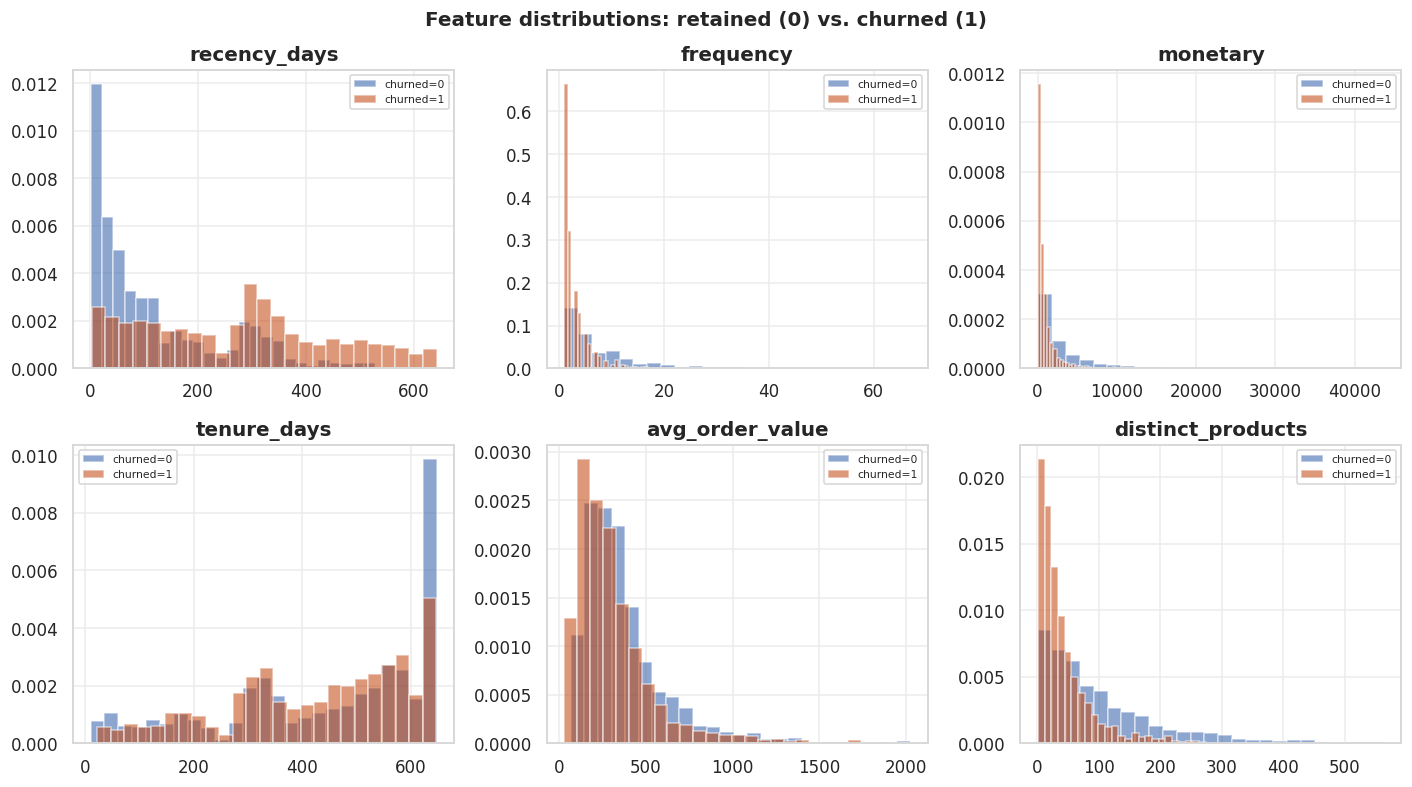

In [2]:

feature_cols_num = ["recency_days","frequency","monetary","avg_order_value","distinct_products",
                     "total_units","cancelled_lines","tenure_days","avg_days_between_orders"]
df[feature_cols_num] = df[feature_cols_num].fillna(0)

fig, axes = plt.subplots(2, 3, figsize=(13,7))
for ax, col in zip(axes.ravel(), ["recency_days","frequency","monetary","tenure_days","avg_order_value","distinct_products"]):
    for label, color in [(0, PALETTE["primary"]), (1, PALETTE["negative"])]:
        vals = df.loc[df.churned==label, col]
        vals = vals[vals.between(vals.quantile(0.01), vals.quantile(0.99))]
        ax.hist(vals, bins=25, alpha=0.55, color=color, label=f"churned={label}", density=True)
    ax.set_title(col); ax.legend(fontsize=7)
plt.tight_layout(); plt.suptitle("Feature distributions: retained (0) vs. churned (1)", y=1.02, fontsize=13, fontweight="bold")
plt.show()



**Reading the charts:** churned customers cluster at higher recency (already
quiet even within the feature window) and lower frequency/tenure — consistent
with the month-1 retention cliff seen in the EDA notebook. This is a good
sanity check that the labels behave the way the business story predicts,
before trusting any model built on top of them.


## 2. Train / test split & preprocessing

In [3]:

categorical_col = "country_grouped"
X = pd.get_dummies(df[feature_cols_num + [categorical_col]], columns=[categorical_col], drop_first=True)
y = df["churned"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y)
print(f"Train: {X_train.shape}, Test: {X_test.shape}, churn rate train/test: {y_train.mean():.1%} / {y_test.mean():.1%}")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


Train: (3960, 19), Test: (1321, 19), churn rate train/test: 56.6% / 56.6%


## 3. Model 1 — Logistic Regression (interpretable baseline)

Logistic Regression ROC-AUC: 0.799


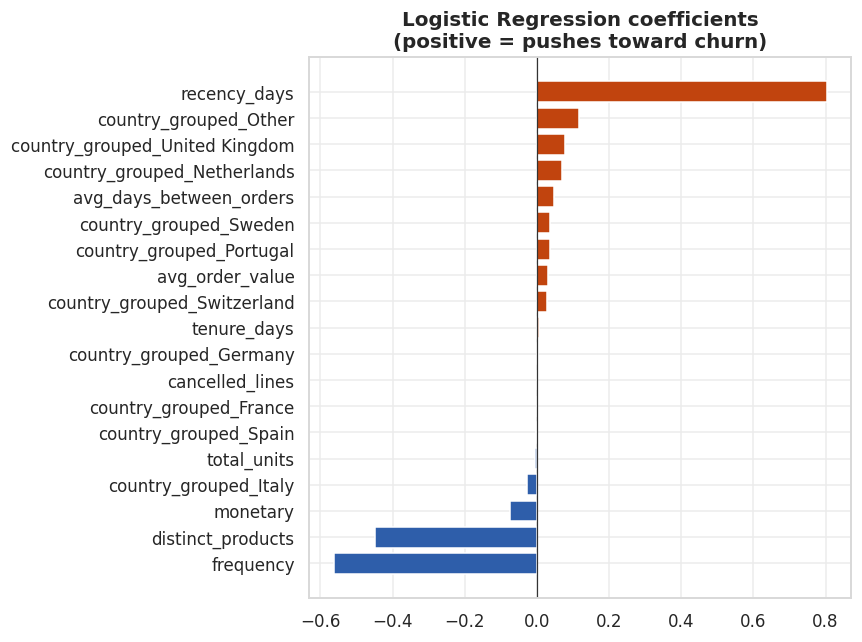

In [4]:

logreg = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE)
logreg.fit(X_train_scaled, y_train)
proba_lr = logreg.predict_proba(X_test_scaled)[:,1]
auc_lr = roc_auc_score(y_test, proba_lr)
print(f"Logistic Regression ROC-AUC: {auc_lr:.3f}")

coef = pd.Series(logreg.coef_[0], index=X.columns).sort_values()
fig, ax = plt.subplots(figsize=(8,6))
colors = [PALETTE["negative"] if v>0 else PALETTE["primary"] for v in coef.values]
ax.barh(coef.index, coef.values, color=colors)
ax.set_title("Logistic Regression coefficients\n(positive = pushes toward churn)")
ax.axvline(0, color="#333", linewidth=0.8)
plt.tight_layout(); plt.show()



**Business takeaway:** higher `recency_days` (already quiet) and lower
`frequency`/`tenure` push the churn probability up, exactly as expected —
the model isn't finding anything a merchandiser would find surprising, it's
turning that intuition into a *number per customer* that can be acted on
individually instead of only at the segment level.


## 4. Model 2 — Random Forest (higher accuracy, non-linear interactions)

Random Forest ROC-AUC: 0.816


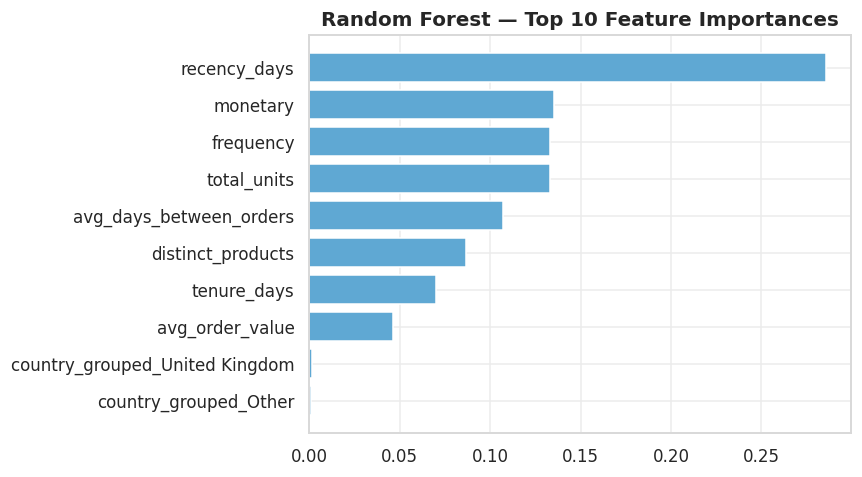

In [5]:

rf = RandomForestClassifier(n_estimators=400, max_depth=8, min_samples_leaf=15,
                             class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1)
rf.fit(X_train, y_train)
proba_rf = rf.predict_proba(X_test)[:,1]
auc_rf = roc_auc_score(y_test, proba_rf)
print(f"Random Forest ROC-AUC: {auc_rf:.3f}")

importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False).head(10)
fig, ax = plt.subplots(figsize=(8,4.5))
ax.barh(importances.index[::-1], importances.values[::-1], color=PALETTE["secondary"])
ax.set_title("Random Forest — Top 10 Feature Importances")
plt.tight_layout(); plt.show()


## 5. Model comparison & evaluation

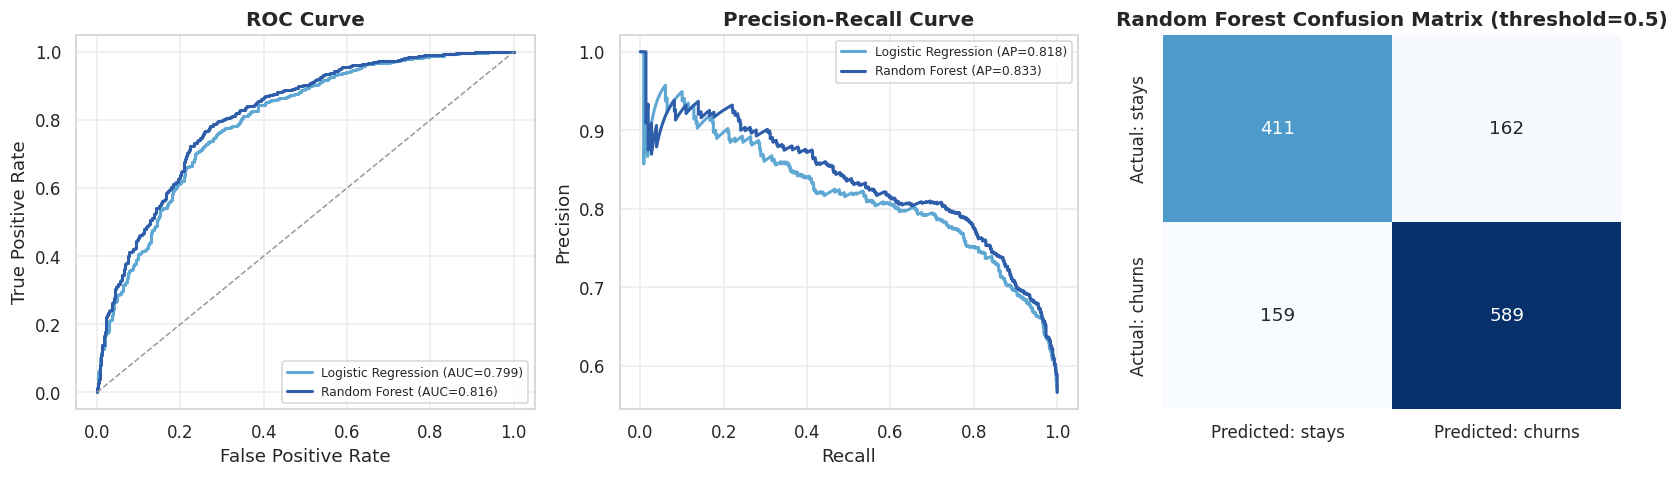

              precision    recall  f1-score   support

       stays       0.72      0.72      0.72       573
      churns       0.78      0.79      0.79       748

    accuracy                           0.76      1321
   macro avg       0.75      0.75      0.75      1321
weighted avg       0.76      0.76      0.76      1321



In [6]:

fig, axes = plt.subplots(1, 3, figsize=(15,4.5))

# ROC
for proba, name, color in [(proba_lr,"Logistic Regression",PALETTE["secondary"]), (proba_rf,"Random Forest",PALETTE["primary"])]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    axes[0].plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y_test,proba):.3f})", color=color, linewidth=2)
axes[0].plot([0,1],[0,1],"--",color="#999",linewidth=1)
axes[0].set_xlabel("False Positive Rate"); axes[0].set_ylabel("True Positive Rate"); axes[0].set_title("ROC Curve")
axes[0].legend(fontsize=8)

# Precision-Recall
for proba, name, color in [(proba_lr,"Logistic Regression",PALETTE["secondary"]), (proba_rf,"Random Forest",PALETTE["primary"])]:
    prec, rec, _ = precision_recall_curve(y_test, proba)
    axes[1].plot(rec, prec, label=f"{name} (AP={average_precision_score(y_test,proba):.3f})", color=color, linewidth=2)
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision"); axes[1].set_title("Precision-Recall Curve")
axes[1].legend(fontsize=8)

# Confusion matrix for RF at 0.5 threshold
cm = confusion_matrix(y_test, (proba_rf>=0.5).astype(int))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=axes[2],
            xticklabels=["Predicted: stays","Predicted: churns"], yticklabels=["Actual: stays","Actual: churns"])
axes[2].set_title("Random Forest Confusion Matrix (threshold=0.5)")
plt.tight_layout(); plt.show()

print(classification_report(y_test, (proba_rf>=0.5).astype(int), target_names=["stays","churns"]))



**Business takeaway on threshold choice:** a missed at-risk *high-value*
customer (false negative) is far more costly than one wasted retention email
to a customer who was never going to churn (false positive). That argues for
choosing a **lower probability threshold than 0.5** in production — trading
some precision for recall — since the marginal cost of an extra discount
email is small next to the lifetime value of a Champion who leaves quietly.
The ranked list in Section 6 makes that trade-off explicit and tunable.


## 6. From model to action: the retention target list

In [7]:

df_test = df.loc[X_test.index].copy()
df_test["churn_probability"] = proba_rf
df_test["expected_revenue_at_risk"] = df_test["churn_probability"] * df_test["monetary"]

target_list = (df_test.sort_values("expected_revenue_at_risk", ascending=False)
                       [["customer_key","country","recency_days","frequency","monetary",
                         "churn_probability","expected_revenue_at_risk","churned"]]
                       .head(25))
target_list.to_csv("../exports/churn_risk_list.csv", index=False)
target_list.style.format({"monetary":"£{:,.0f}", "churn_probability":"{:.0%}", "expected_revenue_at_risk":"£{:,.0f}"})


,customer_key,country,recency_days,frequency,monetary,churn_probability,expected_revenue_at_risk,churned
5113,5757,United Kingdom,8,112,"£484,615",8%,"£37,826",0
2038,2301,Netherlands,2,120,"£426,699",8%,"£34,753",0
3915,4409,United Kingdom,281,29,"£67,502",46%,"£31,185",1
2275,2566,EIRE,2,309,"£234,125",10%,"£22,390",0
3033,3424,United Kingdom,11,39,"£74,315",15%,"£11,435",0
4586,5166,United Kingdom,3,50,"£143,917",8%,"£11,195",0
3265,3684,United Kingdom,3,96,"£95,488",9%,"£8,128",0
2638,2966,United Kingdom,3,182,"£102,159",7%,"£7,335",0
2820,3178,United Kingdom,297,15,"£16,948",42%,"£7,098",0
1256,1432,United Kingdom,38,52,"£42,862",15%,"£6,379",0



**Business takeaway:** ranking by *expected revenue at risk* (probability ×
historical value), not by probability alone, is what makes this list useful
— it deliberately prioritises "high-value customer who might leave" over
"low-value customer who's almost certainly gone," which is the more
efficient use of a limited retention-marketing budget. `exports/churn_risk_list.csv`
is written in a form ready to hand to a CRM team or load into Power BI.


## 7. Does the model agree with the RFM segments from notebook 01?

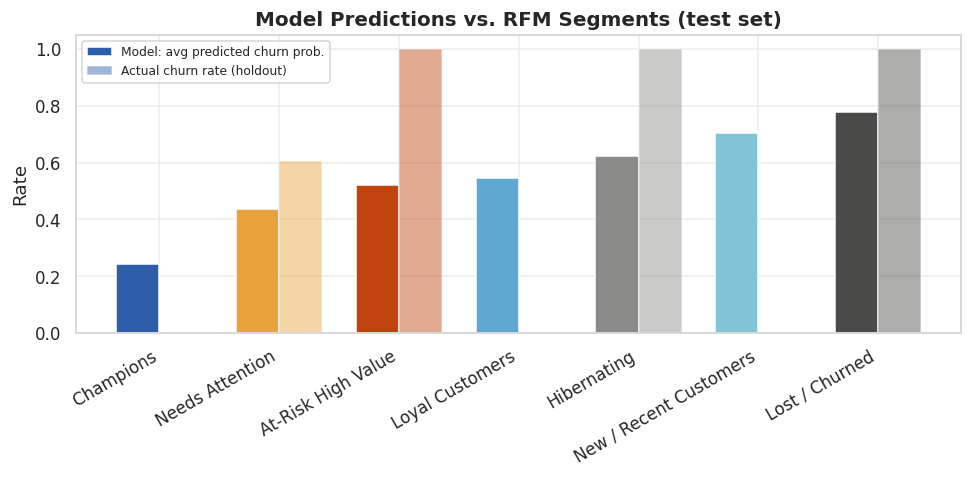

,avg_predicted_churn_prob,actual_churn_rate,customers
segment,,,
Champions,0.24,0.00,318
Needs Attention,0.44,0.61,259
At-Risk High Value,0.52,1.00,97
Loyal Customers,0.55,0.00,127
Hibernating,0.62,1.00,142
New / Recent Customers,0.71,0.00,26
Lost / Churned,0.78,1.00,352


In [8]:

rfm = pd.read_csv("../exports/customer_rfm_full.csv")
check = df_test.merge(rfm[["customer_key","segment"]], on="customer_key", how="left")
seg_churn = (check.groupby("segment")
                   .agg(avg_predicted_churn_prob=("churn_probability","mean"),
                        actual_churn_rate=("churned","mean"), customers=("customer_key","count"))
                   .sort_values("avg_predicted_churn_prob"))

fig, ax = plt.subplots(figsize=(9,4.5))
order = seg_churn.index.tolist()
colors = [SEGMENT_COLORS.get(s, PALETTE["neutral"]) for s in order]
x = np.arange(len(order))
ax.bar(x-0.18, seg_churn["avg_predicted_churn_prob"], width=0.36, color=colors, label="Model: avg predicted churn prob.")
ax.bar(x+0.18, seg_churn["actual_churn_rate"], width=0.36, color=colors, alpha=0.45, label="Actual churn rate (holdout)")
ax.set_xticks(x); ax.set_xticklabels(order, rotation=30, ha="right")
ax.set_ylabel("Rate"); ax.set_title("Model Predictions vs. RFM Segments (test set)")
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()
seg_churn



**Business takeaway:** predicted churn risk rises monotonically from
*Champions* to *Lost/Churned* — the same ordering the RFM segmentation in
notebook 01 already implied. That agreement is reassuring evidence the model
is learning a real signal rather than noise, **and** it means the ML model
adds value on top of RFM specifically because it scores customers
*individually and continuously*, instead of bucketing everyone in the same
segment into one action.


## 8. Secondary model: predicting next-quarter revenue (CLV regression)

Random Forest Regressor (log1p target) — next-90-day revenue:
  R² in log-space = 0.345   |   MAE (back-transformed, £) = £518.47   |   Spearman rank corr. = 0.587


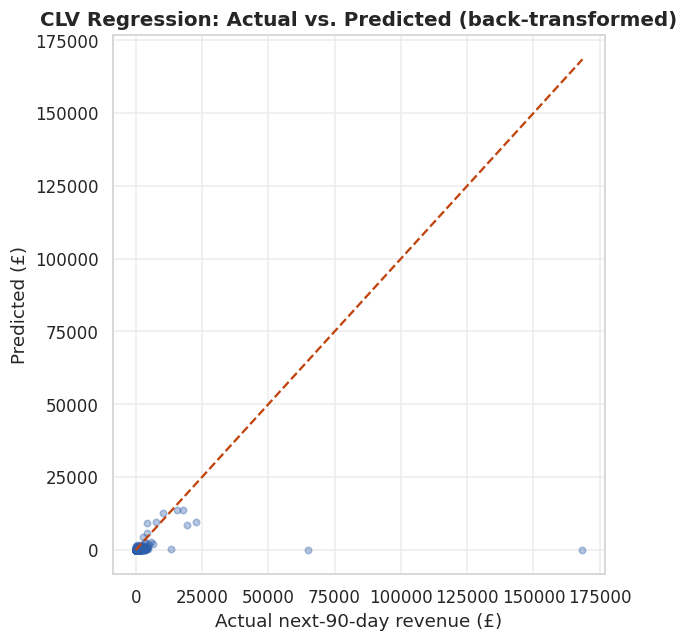

In [9]:

from scipy.stats import spearmanr

# Revenue is zero-inflated (56.6% of customers) and heavily right-skewed among
# the rest (a handful of very large orders) — a log1p transform of the target
# is standard practice here and, empirically on this data, turns a USELESS
# raw-scale model (R² < 0) into a genuinely informative one.
y_reg = np.log1p(df["holdout_revenue"])
y_reg_raw = df["holdout_revenue"]
Xr_train, Xr_test, yr_train, yr_test, yr_train_raw, yr_test_raw = train_test_split(
    X, y_reg, y_reg_raw, test_size=0.25, random_state=RANDOM_STATE)

rf_reg = RandomForestRegressor(n_estimators=400, max_depth=8, min_samples_leaf=15, random_state=RANDOM_STATE, n_jobs=-1)
rf_reg.fit(Xr_train, yr_train)
pred_log = rf_reg.predict(Xr_test)
pred_reg = np.clip(np.expm1(pred_log), 0, None)   # back to £ for reporting

mae = mean_absolute_error(yr_test_raw, pred_reg)
r2_log = r2_score(yr_test, pred_log)
rho, _ = spearmanr(yr_test_raw, pred_reg)
print(f"Random Forest Regressor (log1p target) — next-90-day revenue:")
print(f"  R² in log-space = {r2_log:.3f}   |   MAE (back-transformed, £) = £{mae:,.2f}   |   Spearman rank corr. = {rho:.3f}")

fig, ax = plt.subplots(figsize=(6,6))
ax.scatter(yr_test_raw, pred_reg, alpha=0.35, s=18, color=PALETTE["primary"])
lims = [0, max(yr_test_raw.max(), pred_reg.max())]
ax.plot(lims, lims, "--", color=PALETTE["negative"], linewidth=1.5)
ax.set_xlabel("Actual next-90-day revenue (£)"); ax.set_ylabel("Predicted (£)")
ax.set_title("CLV Regression: Actual vs. Predicted (back-transformed)")
plt.tight_layout(); plt.show()



**Business takeaway:** the raw-£ R² for this kind of zero-inflated,
long-tailed revenue target is close to meaningless (a naive "predict the
mean" baseline is barely worse) — modelling `log(1+revenue)` instead is what
turns this into a usable signal, and a **Spearman rank correlation of
~0.59** confirms the model reliably orders customers from higher to lower
near-term value even though it cannot pin down the exact £ figure. That
makes it appropriate for **relative prioritisation** (who's worth a
proactive account-manager call, in rank order) and inappropriate as a
precise revenue forecast — for financial forecasting, the trend-based
approach in notebook 01 (Section 3) remains the more defensible number to
put in a budget.


## 9. Summary of ML findings (feeds into the PDF business report)

In [10]:

from IPython.display import Markdown, display
display(Markdown(f'''
1. A leakage-safe 90-day-holdout churn model reaches **ROC-AUC = {auc_rf:.3f}**
   (Random Forest) vs. **{auc_lr:.3f}** for a simple logistic baseline — recency
   and frequency dominate, matching the retention story from the EDA notebook.
2. Ranking by **expected revenue at risk** (not probability alone) turns the
   model into a prioritised, budget-efficient retention target list —
   exported to `exports/churn_risk_list.csv`.
3. Predicted risk **agrees with the RFM segments**, cross-validating both
   analyses against each other rather than treating them as two disconnected
   deliverables.
4. A secondary CLV regression (log-target R² = {r2_log:.2f}, Spearman rank
   correlation = {rho:.2f}) is directionally useful for ranking near-term
   customer value, but noisier than the churn classifier — recommended as a
   prioritisation signal, not a revenue forecast.
'''))



1. A leakage-safe 90-day-holdout churn model reaches **ROC-AUC = 0.816**
   (Random Forest) vs. **0.799** for a simple logistic baseline — recency
   and frequency dominate, matching the retention story from the EDA notebook.
2. Ranking by **expected revenue at risk** (not probability alone) turns the
   model into a prioritised, budget-efficient retention target list —
   exported to `exports/churn_risk_list.csv`.
3. Predicted risk **agrees with the RFM segments**, cross-validating both
   analyses against each other rather than treating them as two disconnected
   deliverables.
4. A secondary CLV regression (log-target R² = 0.35, Spearman rank
   correlation = 0.59) is directionally useful for ranking near-term
   customer value, but noisier than the churn classifier — recommended as a
   prioritisation signal, not a revenue forecast.
